### Modelling strategy

In this section, we estimate two different prediction settings in order to distinguish between **next-day effects** and **same-day premarket effects**.

**Next-day modelling** asks whether information from Trump’s posts on day *t* helps predict market outcomes on day *t+1*. In this setup, the target variables are `next_market_up` for classification and `next_log_return` for regression. The goal is to test whether today’s posting activity, sentiment, engagement, and semantic features contain information about the **next trading day**. This is the main setting for studying delayed market reactions.

**Premarket modelling** asks whether information that is available **before the market opens** can help predict returns on the **same trading day**. Here, the target variables are `market_up` and `log_return`, but the input features are restricted to premarket variables such as `*_premarket` sentiment, posting counts, and engagement measures, together with lagged market controls. The purpose of this setup is to test whether Trump-related signals have immediate predictive value that could in principle be used before trading starts.

We keep these two modelling settings separate because they answer different research questions. Next-day modelling captures whether market effects emerge with a short delay, while premarket modelling captures whether there is an observable signal already available before the trading session begins.

Within each setting, we compare **classification** and **regression** tasks. Classification focuses on the **direction** of the market move, that is, whether the market goes up or down. Regression focuses on the **magnitude** of the move, that is, the size of the return. This distinction is important because predicting direction is often easier than predicting the exact return size.

To evaluate the models in a realistic way, we use a **chronological split** rather than a random train-test split. The training period covers **2009–2020**, the validation period covers **2022–2023**, and the final test period covers **2024–2025**. This preserves temporal order and avoids look-ahead bias. In addition, we apply **TimeSeriesSplit cross-validation** within the training data to make model selection more robust.

Finally, we compare different **feature sets** to test whether more complex text information adds predictive value beyond standard market controls. We start with a market-only baseline, then add simple NLP variables such as posting frequency and sentiment, then richer handcrafted text features, and finally semantic features such as embeddings and clusters. This allows us to assess whether Trump-related text signals improve prediction beyond information already contained in past market movements.

### 1. Setup, load data, define splits and feature sets

In [26]:
# 1) Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge, ElasticNet
from sklearn.svm import LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.neural_network import MLPClassifier, MLPRegressor


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [27]:
# 2) Global settings
SEED = 42
N_SPLITS_CV = 5
RUN_MLP = False   # set True if you also want a neural-network benchmark

In [28]:
# 3) Paths and data loading
# Notebook location: nlp-final-project/5_modelling
# Feature files:     nlp-final-project/3_feature_engineering/features

PROJECT_ROOT = Path("..").resolve()
FEATURES_DIR = PROJECT_ROOT / "3_feature_engineering" / "features"

print("Project root:", PROJECT_ROOT)
print("Features dir exists:", FEATURES_DIR.exists())
print("Feature matrix exists:", (FEATURES_DIR / "feature_matrix.csv").exists())

# Load feature matrix
df = pd.read_csv(FEATURES_DIR / "feature_matrix.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Drop helper columns that should not be used directly as model inputs
df = df.drop(columns=["date_only", "dominant_cluster"], errors="ignore")

# Convert cluster dummies to integers
cluster_cols = [c for c in df.columns if c.startswith("cluster_")]
for col in cluster_cols:
    df[col] = df[col].astype(int)

# Premarket missing values usually mean: no premarket post
premarket_cols = [c for c in df.columns if c.endswith("_premarket")]
df[premarket_cols] = df[premarket_cols].fillna(0)

# Explicit indicator for premarket activity
if "post_count_premarket" in df.columns:
    df["has_premarket_post"] = (df["post_count_premarket"] > 0).astype(int)
else:
    df["has_premarket_post"] = 0

print("Shape:", df.shape)
df.head()

Project root: C:\Dev\nlp-final-project
Features dir exists: True
Feature matrix exists: True
Shape: (3526, 95)


,date,Close,High,Low,Open,Volume,log_return,abs_return,intraday_range,next_log_return,...,cluster_topic_13,cluster_topic_2,cluster_topic_3,cluster_topic_4,cluster_topic_5,cluster_topic_6,cluster_topic_7,cluster_topic_8,cluster_topic_9,has_premarket_post
0,2009-05-04,907.24,907.85,879.21,879.21,7038840000,0.033868,0.033868,0.032575,-0.003792,...,0,0,0,0,0,0,0,0,0,0
1,2009-05-08,929.23,930.17,909.03,909.03,8163280000,0.024069,0.024069,0.023256,-0.021512,...,0,0,0,0,0,0,0,0,0,1
2,2009-05-12,908.35,915.57,896.46,910.52,6871750000,-0.000979,0.000979,0.020988,-0.026895,...,0,0,0,0,0,0,0,0,0,0
3,2009-05-13,883.92,905.40,882.80,905.40,7091820000,-0.026895,0.026895,0.024961,0.010352,...,0,0,0,0,0,0,0,0,0,0
4,2009-05-14,893.07,898.36,882.52,884.24,6134870000,0.010352,0.010352,0.017914,-0.011410,...,0,0,0,0,0,0,0,1,0,0


In [29]:
# 4) Chronological split
def assign_split(date_value):
    if pd.Timestamp("2009-01-01") <= date_value <= pd.Timestamp("2020-12-31"):
        return "train"
    elif pd.Timestamp("2022-01-01") <= date_value <= pd.Timestamp("2023-12-31"):
        return "valid"
    elif pd.Timestamp("2024-01-01") <= date_value <= pd.Timestamp("2025-12-31"):
        return "test"
    else:
        return "unused"

df["split"] = df["date"].apply(assign_split)
model_df = df[df["split"] != "unused"].copy()

print(model_df["split"].value_counts())
model_df.groupby("split")["date"].agg(["min", "max", "count"])

split
train    2596
test      500
valid     420
Name: count, dtype: int64


,min,max,count
split,,,
test,2024-01-02,2025-12-31,500
train,2009-05-04,2020-12-31,2596
valid,2022-02-14,2023-12-29,420


In [30]:
# 5) Feature groups

market_base = [
    "return_lag1",
    "return_lag2",
    "vol_5d",
    "vol_20d"
]

simple_daily_nlp = [
    "post_count",
    "vader_mean",
    "vader_std",
    "finbert_mean",
    "finbert_std",
    "max_engagement",
    "mean_word_count"
]

advanced_daily_nlp = [
    "vader_max_pos",
    "vader_max_neg",
    "caps_ratio_mean",
    "exclamation_mean",
    "exclamation_max",
    "topic_trade",
    "topic_fed",
    "topic_energy",
    "topic_tax",
    "topic_sanctions",
    "topic_market_direct",
    "topic_immigration",
    "topic_geopolitics",
    "vader_3d_rolling",
    "vader_7d_rolling",
    "vader_momentum",
    "daily_mention_count",
    "daily_has_mention",
    "daily_reply_count"
]

semantic_daily = [
    "emb_diversity",
    "novelty_score"
] + cluster_cols

simple_premarket_nlp = [
    "has_premarket_post",
    "post_count_premarket",
    "vader_mean_premarket",
    "vader_std_premarket",
    "finbert_mean_premarket",
    "finbert_std_premarket",
    "max_engagement_premarket",
    "mean_word_count_premarket"
]

advanced_premarket_nlp = [
    "vader_max_pos_premarket",
    "vader_max_neg_premarket",
    "caps_ratio_mean_premarket",
    "exclamation_mean_premarket",
    "exclamation_max_premarket",
    "topic_trade_premarket",
    "topic_fed_premarket",
    "topic_energy_premarket",
    "topic_tax_premarket",
    "topic_sanctions_premarket",
    "topic_market_direct_premarket",
    "topic_immigration_premarket",
    "topic_geopolitics_premarket"
]

def keep_existing(columns, frame):
    return [c for c in columns if c in frame.columns]

next_day_feature_sets = {
    "market_only": keep_existing(market_base, model_df),
    "market_plus_simple_nlp": keep_existing(market_base + simple_daily_nlp, model_df),
    "market_plus_full_nlp": keep_existing(market_base + simple_daily_nlp + advanced_daily_nlp, model_df),
    "market_plus_semantic": keep_existing(market_base + simple_daily_nlp + advanced_daily_nlp + semantic_daily, model_df)
}

premarket_feature_sets = {
    "market_only": keep_existing(market_base, model_df),
    "market_plus_simple_premarket": keep_existing(market_base + simple_premarket_nlp, model_df),
    "market_plus_full_premarket": keep_existing(market_base + simple_premarket_nlp + advanced_premarket_nlp, model_df)
}

print("Next-day feature sets:")
for k, v in next_day_feature_sets.items():
    print(f"{k}: {len(v)} features")

print("\nPremarket feature sets:")
for k, v in premarket_feature_sets.items():
    print(f"{k}: {len(v)} features")

Next-day feature sets:
market_only: 4 features
market_plus_simple_nlp: 11 features
market_plus_full_nlp: 19 features
market_plus_semantic: 36 features

Premarket feature sets:
market_only: 4 features
market_plus_simple_premarket: 12 features
market_plus_full_premarket: 17 features


In [31]:
# 6) Modeling scenarios
SCENARIOS = {
    "next_day_classification": {
        "task": "classification",
        "target": "next_market_up",
        "feature_sets": next_day_feature_sets
    },
    "next_day_regression": {
        "task": "regression",
        "target": "next_log_return",
        "feature_sets": next_day_feature_sets
    },
    "premarket_classification": {
        "task": "classification",
        "target": "market_up",
        "feature_sets": premarket_feature_sets
    },
    "premarket_regression": {
        "task": "regression",
        "target": "log_return",
        "feature_sets": premarket_feature_sets
    }
}

### 2. Helper functions for model training and evaluation

In [32]:
# 7) Helper functions

def make_model(task, model_name, random_state=SEED):
    """
    Build a sklearn pipeline:
    1. median imputation
    2. optional scaling
    3. estimator
    """
    scale_models = {"logreg", "linear_svm", "ridge", "elastic_net", "mlp"}

    if task == "classification":
        model_dict = {
            "dummy": DummyClassifier(strategy="most_frequent"),
            "logreg": LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=random_state
            ),
            "linear_svm": LinearSVC(
                class_weight="balanced",
                dual="auto",
                max_iter=5000,
                random_state=random_state
            ),
            "random_forest": RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=5,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=random_state
            ),
            "gradient_boosting": GradientBoostingClassifier(
                random_state=random_state
            )
        }

        if RUN_MLP:
            model_dict["mlp"] = MLPClassifier(
                hidden_layer_sizes=(64, 32),
                alpha=1e-3,
                max_iter=500,
                random_state=random_state
            )

    elif task == "regression":
        model_dict = {
            "dummy": DummyRegressor(strategy="mean"),
            "ridge": Ridge(alpha=1.0),
            "elastic_net": ElasticNet(
                alpha=0.01,
                l1_ratio=0.5,
                max_iter=5000,
                random_state=random_state
            ),
            "random_forest": RandomForestRegressor(
                n_estimators=200,
                min_samples_leaf=5,
                n_jobs=-1,
                random_state=random_state
            ),
            "gradient_boosting": GradientBoostingRegressor(
                random_state=random_state
            )
        }

        if RUN_MLP:
            model_dict["mlp"] = MLPRegressor(
                hidden_layer_sizes=(64, 32),
                alpha=1e-3,
                max_iter=500,
                random_state=random_state
            )
    else:
        raise ValueError("task must be 'classification' or 'regression'")

    steps = [("imputer", SimpleImputer(strategy="median"))]

    if model_name in scale_models:
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model_dict[model_name]))
    return Pipeline(steps)

In [33]:
# 8) Scoring helpers

def get_classification_score_signal(fitted_model, X):
    """
    Return scores for ROC-AUC.
    Uses predict_proba if available, otherwise decision_function.
    """
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]
    elif hasattr(fitted_model, "decision_function"):
        score = fitted_model.decision_function(X)
        if np.ndim(score) > 1:
            return score[:, 1]
        return score
    else:
        return fitted_model.predict(X)

def evaluate_classification(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score)
    }

def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    return {
        "rmse": rmse,
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

def get_cv_scoring(task):
    if task == "classification":
        return "roc_auc"
    elif task == "regression":
        return "neg_mean_squared_error"
    else:
        raise ValueError("task must be 'classification' or 'regression'")

def sort_results(results_df, task):
    if task == "classification":
        return results_df.sort_values(
            by=["valid_roc_auc", "valid_balanced_accuracy", "cv_mean"],
            ascending=[False, False, False]
        )
    else:
        return results_df.sort_values(
            by=["valid_rmse", "valid_mae", "cv_mean_rmse"],
            ascending=[True, True, True]
        )

In [34]:
# 9) Training and testing functions

def run_model_search(data, scenario_name, scenario_config):
    """
    1. Train on train split
    2. Run TimeSeriesSplit CV inside the train split
    3. Fit on the full train split
    4. Evaluate on the validation split
    """
    task = scenario_config["task"]
    target = scenario_config["target"]
    feature_sets = scenario_config["feature_sets"]

    train_df = data[data["split"] == "train"].dropna(subset=[target]).copy()
    valid_df = data[data["split"] == "valid"].dropna(subset=[target]).copy()

    if task == "classification":
        model_names = ["dummy", "logreg", "linear_svm", "random_forest", "gradient_boosting"]
        if RUN_MLP:
            model_names.append("mlp")
    else:
        model_names = ["dummy", "ridge", "elastic_net", "random_forest", "gradient_boosting"]
        if RUN_MLP:
            model_names.append("mlp")

    rows = []
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
    cv_scoring = get_cv_scoring(task)

    for feature_set_name, feature_cols in feature_sets.items():
        X_train = train_df[feature_cols]
        y_train = train_df[target]

        X_valid = valid_df[feature_cols]
        y_valid = valid_df[target]

        for model_name in model_names:
            model = make_model(task, model_name)

            cv_scores = cross_val_score(
                estimator=model,
                X=X_train,
                y=y_train,
                cv=tscv,
                scoring=cv_scoring,
                n_jobs=1,
                error_score=np.nan
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_valid)

            row = {
                "scenario": scenario_name,
                "task": task,
                "target": target,
                "feature_set": feature_set_name,
                "n_features": len(feature_cols),
                "model": model_name
            }

            if task == "classification":
                row["cv_mean"] = np.nanmean(cv_scores)
                row["cv_std"] = np.nanstd(cv_scores)

                y_score = get_classification_score_signal(model, X_valid)
                valid_metrics = evaluate_classification(y_valid, y_pred, y_score)

            else:
                # cv_scores are negative MSE -> convert to RMSE
                cv_rmse_scores = np.sqrt(-cv_scores)

                row["cv_mean_rmse"] = np.nanmean(cv_rmse_scores)
                row["cv_std_rmse"] = np.nanstd(cv_rmse_scores)

                valid_metrics = evaluate_regression(y_valid, y_pred)

            for metric_name, metric_value in valid_metrics.items():
                row[f"valid_{metric_name}"] = metric_value

            rows.append(row)

    results_df = pd.DataFrame(rows)
    results_df = sort_results(results_df, task).reset_index(drop=True)
    return results_df


def refit_best_and_test(data, scenario_name, scenario_config, validation_results):
    """
    1. Pick the best validation model
    2. Refit it on train + validation
    3. Evaluate once on the final test set
    """
    task = scenario_config["task"]
    target = scenario_config["target"]
    feature_sets = scenario_config["feature_sets"]

    best_row = validation_results.iloc[0].copy()
    best_feature_set = best_row["feature_set"]
    best_model_name = best_row["model"]

    feature_cols = feature_sets[best_feature_set]

    train_valid_df = data[data["split"].isin(["train", "valid"])].dropna(subset=[target]).copy()
    test_df = data[data["split"] == "test"].dropna(subset=[target]).copy()

    X_train_valid = train_valid_df[feature_cols]
    y_train_valid = train_valid_df[target]

    X_test = test_df[feature_cols]
    y_test = test_df[target]

    final_model = make_model(task, best_model_name)
    final_model.fit(X_train_valid, y_train_valid)
    y_pred = final_model.predict(X_test)

    result = {
        "scenario": scenario_name,
        "task": task,
        "target": target,
        "selected_feature_set": best_feature_set,
        "selected_model": best_model_name,
        "n_features": len(feature_cols)
    }

    if task == "classification":
        y_score = get_classification_score_signal(final_model, X_test)
        test_metrics = evaluate_classification(y_test, y_pred, y_score)
    else:
        test_metrics = evaluate_regression(y_test, y_pred)

    for metric_name, metric_value in test_metrics.items():
        result[f"test_{metric_name}"] = metric_value

    return pd.DataFrame([result]), final_model, feature_cols

### 3. Run all four modeling scenarios

In [35]:
# 10) Run all scenarios

validation_tables = {}
test_tables = {}
fitted_models = {}
selected_feature_columns = {}

for scenario_name, scenario_config in SCENARIOS.items():
    print("\n" + "=" * 80)
    print(f"Running scenario: {scenario_name}")
    print("=" * 80)

    valid_results = run_model_search(model_df, scenario_name, scenario_config)
    validation_tables[scenario_name] = valid_results

    print("\nTop validation results:")
    print(valid_results.head(10))

    test_result, fitted_model, feature_cols = refit_best_and_test(
        data=model_df,
        scenario_name=scenario_name,
        scenario_config=scenario_config,
        validation_results=valid_results
    )

    test_tables[scenario_name] = test_result
    fitted_models[scenario_name] = fitted_model
    selected_feature_columns[scenario_name] = feature_cols

    print("\nFinal test result:")
    print(test_result)


Running scenario: next_day_classification

Top validation results:
                  scenario            task          target  \
0  next_day_classification  classification  next_market_up   
1  next_day_classification  classification  next_market_up   
2  next_day_classification  classification  next_market_up   
3  next_day_classification  classification  next_market_up   
4  next_day_classification  classification  next_market_up   
5  next_day_classification  classification  next_market_up   
6  next_day_classification  classification  next_market_up   
7  next_day_classification  classification  next_market_up   
8  next_day_classification  classification  next_market_up   
9  next_day_classification  classification  next_market_up   

              feature_set  n_features              model   cv_mean    cv_std  \
0    market_plus_semantic          36  gradient_boosting  0.498584  0.025824   
1  market_plus_simple_nlp          11  gradient_boosting  0.482014  0.033503   
2  market

### Interpretation of the modelling results

The modelling results show that **classification performs slightly better than regression**, but overall predictive power remains limited.

For **next-day classification**, the best test model was a **Random Forest** using the `market_plus_simple_nlp` feature set. This model achieved an **accuracy of 0.562**, a **balanced accuracy of 0.533**, and a **ROC-AUC of 0.548**. This suggests that simple NLP features such as posting activity, sentiment, and engagement contain a **small predictive signal** for next-day market direction. However, the effect is weak, and performance is only modestly above chance.

For **next-day regression**, the best model was the **dummy baseline** with the `market_only` feature set. The test **R² of -0.001** indicates that the model does **not explain return magnitude better than a naive baseline**. In other words, the available features do not meaningfully predict the size of next-day returns.

For **premarket classification**, the best test model was again a **Random Forest**, but this time using only the `market_only` feature set. Its **ROC-AUC of 0.530** indicates that same-day market direction can be predicted only **very weakly**, and that the premarket Trump-related features do not add clear predictive value beyond standard market variables.

For **premarket regression**, the best model was also based on `market_only`, with a **test R² of -0.059**. This confirms that the return magnitude cannot be predicted reliably in the premarket setting either.

Overall, the results suggest that **predicting market direction is slightly more feasible than predicting return magnitude**. The most promising setup is the **next-day classification task with simple NLP features**, while more complex semantic or premarket feature sets do not appear to improve performance in a meaningful way.

In [36]:
# 11) Combine all results

all_validation_results = pd.concat(validation_tables.values(), ignore_index=True)
all_test_results = pd.concat(test_tables.values(), ignore_index=True)

print("Validation results shape:", all_validation_results.shape)
print("Test results shape:", all_test_results.shape)

all_validation_results.head(25)

Validation results shape: (70, 17)
Test results shape: (4, 13)


,scenario,task,target,feature_set,n_features,model,cv_mean,cv_std,valid_accuracy,valid_balanced_accuracy,valid_f1,valid_roc_auc,cv_mean_rmse,cv_std_rmse,valid_rmse,valid_mae,valid_r2
0,next_day_classification,classification,next_market_up,market_plus_semantic,36,gradient_boosting,0.498584,0.025824,0.533333,0.533935,0.584746,0.538062,NaN,NaN,NaN,NaN,NaN
1,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,gradient_boosting,0.482014,0.033503,0.500000,0.501259,0.603774,0.510420,NaN,NaN,NaN,NaN,NaN
2,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,random_forest,0.501941,0.026634,0.492857,0.494036,0.592734,0.505000,NaN,NaN,NaN,NaN,NaN
3,next_day_classification,classification,next_market_up,market_only,4,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000,NaN,NaN,NaN,NaN,NaN
4,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000,NaN,NaN,NaN,NaN,NaN
5,next_day_classification,classification,next_market_up,market_plus_full_nlp,19,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000,NaN,NaN,NaN,NaN,NaN
6,next_day_classification,classification,next_market_up,market_plus_semantic,36,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000,NaN,NaN,NaN,NaN,NaN
7,next_day_classification,classification,next_market_up,market_plus_full_nlp,19,gradient_boosting,0.500061,0.030744,0.480952,0.482619,0.614841,0.495680,NaN,NaN,NaN,NaN,NaN
8,next_day_classification,classification,next_market_up,market_plus_semantic,36,linear_svm,0.516908,0.031255,0.523810,0.523527,0.492386,0.483911,NaN,NaN,NaN,NaN,NaN
9,next_day_classification,classification,next_market_up,market_plus_semantic,36,logreg,0.517061,0.030988,0.519048,0.518765,0.487310,0.483616,NaN,NaN,NaN,NaN,NaN


### 4. Clean result tables for interpretation

In [37]:
# 12) Classification result tables

classification_validation = all_validation_results[
    all_validation_results["task"] == "classification"
].sort_values(
    by=["scenario", "valid_roc_auc", "valid_balanced_accuracy"],
    ascending=[True, False, False]
)

classification_test = all_test_results[
    all_test_results["task"] == "classification"
].sort_values(
    by=["scenario", "test_roc_auc", "test_balanced_accuracy"],
    ascending=[True, False, False]
)

print("Top classification validation results:")
display(classification_validation.groupby("scenario").head(5))

print("\nFinal classification test results:")
display(classification_test)

Top classification validation results:


,scenario,task,target,feature_set,n_features,model,cv_mean,cv_std,valid_accuracy,valid_balanced_accuracy,valid_f1,valid_roc_auc,cv_mean_rmse,cv_std_rmse,valid_rmse,valid_mae,valid_r2
0,next_day_classification,classification,next_market_up,market_plus_semantic,36,gradient_boosting,0.498584,0.025824,0.533333,0.533935,0.584746,0.538062,NaN,NaN,NaN,NaN,NaN
1,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,gradient_boosting,0.482014,0.033503,0.500000,0.501259,0.603774,0.510420,NaN,NaN,NaN,NaN,NaN
2,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,random_forest,0.501941,0.026634,0.492857,0.494036,0.592734,0.505000,NaN,NaN,NaN,NaN,NaN
3,next_day_classification,classification,next_market_up,market_only,4,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000,NaN,NaN,NaN,NaN,NaN
4,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000,NaN,NaN,NaN,NaN,NaN
40,premarket_classification,classification,market_up,market_only,4,random_forest,0.521454,0.042551,0.528571,0.528571,0.556054,0.536667,NaN,NaN,NaN,NaN,NaN
41,premarket_classification,classification,market_up,market_plus_simple_premarket,12,random_forest,0.507062,0.028189,0.495238,0.495238,0.511521,0.514853,NaN,NaN,NaN,NaN,NaN
42,premarket_classification,classification,market_up,market_only,4,gradient_boosting,0.511517,0.034404,0.504762,0.504762,0.588933,0.513923,NaN,NaN,NaN,NaN,NaN
43,premarket_classification,classification,market_up,market_only,4,dummy,0.500000,0.000000,0.500000,0.500000,0.666667,0.500000,NaN,NaN,NaN,NaN,NaN
44,premarket_classification,classification,market_up,market_plus_simple_premarket,12,dummy,0.500000,0.000000,0.500000,0.500000,0.666667,0.500000,NaN,NaN,NaN,NaN,NaN



Final classification test results:


,scenario,task,target,selected_feature_set,selected_model,n_features,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,test_rmse,test_mae,test_r2
0,next_day_classification,classification,next_market_up,market_plus_semantic,gradient_boosting,36,0.586,0.549795,0.687783,0.593414,NaN,NaN,NaN
2,premarket_classification,classification,market_up,market_only,random_forest,4,0.538,0.534981,0.579235,0.530668,NaN,NaN,NaN


In [38]:
# 13) Regression result tables

regression_validation = all_validation_results[
    all_validation_results["task"] == "regression"
].sort_values(
    by=["scenario", "valid_rmse", "valid_mae"],
    ascending=[True, True, True]
)

regression_test = all_test_results[
    all_test_results["task"] == "regression"
].sort_values(
    by=["scenario", "test_rmse", "test_mae"],
    ascending=[True, True, True]
)

print("Top regression validation results:")
display(regression_validation.groupby("scenario").head(5))

print("\nFinal regression test results:")
display(regression_test)

Top regression validation results:


,scenario,task,target,feature_set,n_features,model,cv_mean,cv_std,valid_accuracy,valid_balanced_accuracy,valid_f1,valid_roc_auc,cv_mean_rmse,cv_std_rmse,valid_rmse,valid_mae,valid_r2
20,next_day_regression,regression,next_log_return,market_only,4,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
21,next_day_regression,regression,next_log_return,market_only,4,elastic_net,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
22,next_day_regression,regression,next_log_return,market_plus_simple_nlp,11,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
23,next_day_regression,regression,next_log_return,market_plus_simple_nlp,11,elastic_net,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
24,next_day_regression,regression,next_log_return,market_plus_full_nlp,19,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
55,premarket_regression,regression,log_return,market_only,4,random_forest,NaN,NaN,NaN,NaN,NaN,NaN,0.010140,0.003745,0.012004,0.008763,0.001166
56,premarket_regression,regression,log_return,market_only,4,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057
57,premarket_regression,regression,log_return,market_only,4,elastic_net,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057
58,premarket_regression,regression,log_return,market_plus_simple_premarket,12,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057
59,premarket_regression,regression,log_return,market_plus_simple_premarket,12,elastic_net,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057



Final regression test results:


,scenario,task,target,selected_feature_set,selected_model,n_features,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,test_rmse,test_mae,test_r2
1,next_day_regression,regression,next_log_return,market_only,dummy,4,NaN,NaN,NaN,NaN,0.010065,0.006594,-0.001095
3,premarket_regression,regression,log_return,market_only,random_forest,4,NaN,NaN,NaN,NaN,0.010295,0.006727,-0.058467


In [39]:
# 14) Best model per scenario

best_validation_per_scenario = (
    all_validation_results
    .groupby("scenario", as_index=False)
    .first()
)

display(best_validation_per_scenario)

,scenario,task,target,feature_set,n_features,model,cv_mean,cv_std,valid_accuracy,valid_balanced_accuracy,valid_f1,valid_roc_auc,cv_mean_rmse,cv_std_rmse,valid_rmse,valid_mae,valid_r2
0,next_day_classification,classification,next_market_up,market_plus_semantic,36,gradient_boosting,0.498584,0.025824,0.533333,0.533935,0.584746,0.538062,NaN,NaN,NaN,NaN,NaN
1,next_day_regression,regression,next_log_return,market_only,4,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
2,premarket_classification,classification,market_up,market_only,4,random_forest,0.521454,0.042551,0.528571,0.528571,0.556054,0.536667,NaN,NaN,NaN,NaN,NaN
3,premarket_regression,regression,log_return,market_only,4,random_forest,NaN,NaN,NaN,NaN,NaN,NaN,0.010140,0.003745,0.012004,0.008763,0.001166


### 5. Optional model interpretation with permutation importance

In [40]:
# 15) Permutation importance
from sklearn.inspection import permutation_importance

def permutation_importance_table(model, X, y, task, random_state=SEED):
    scoring = "roc_auc" if task == "classification" else "neg_root_mean_squared_error"

    perm = permutation_importance(
        estimator=model,
        X=X,
        y=y,
        n_repeats=10,
        random_state=random_state,
        scoring=scoring,
        n_jobs=1
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    return out

In [41]:
# 16) Example: inspect the final next-day classification model

scenario_to_inspect = "next_day_classification"

feature_cols = selected_feature_columns[scenario_to_inspect]
final_model = fitted_models[scenario_to_inspect]
task = SCENARIOS[scenario_to_inspect]["task"]
target = SCENARIOS[scenario_to_inspect]["target"]

test_df = model_df[model_df["split"] == "test"].dropna(subset=[target]).copy()
X_test = test_df[feature_cols]
y_test = test_df[target]

importance_table = permutation_importance_table(final_model, X_test, y_test, task)
display(importance_table.head(20))

,feature,importance_mean,importance_std
10,mean_word_count,0.041028,0.017005
8,finbert_std,0.028869,0.008003
6,vader_std,0.023309,0.010211
17,vader_7d_rolling,0.010363,0.003810
16,vader_3d_rolling,0.010163,0.005954
5,vader_mean,0.009506,0.005742
1,return_lag2,0.005981,0.004397
7,finbert_mean,0.005336,0.002292
0,return_lag1,0.005138,0.007110
13,caps_ratio_mean,0.004754,0.009476


### 6. Save results

In [42]:
# 17) Save outputs
RESULTS_DIR = PROJECT_ROOT / "5_modelling" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

all_validation_results.to_csv(RESULTS_DIR / "all_validation_results.csv", index=False)
all_test_results.to_csv(RESULTS_DIR / "all_test_results.csv", index=False)
classification_validation.to_csv(RESULTS_DIR / "classification_validation.csv", index=False)
classification_test.to_csv(RESULTS_DIR / "classification_test.csv", index=False)
regression_validation.to_csv(RESULTS_DIR / "regression_validation.csv", index=False)
regression_test.to_csv(RESULTS_DIR / "regression_test.csv", index=False)
best_validation_per_scenario.to_csv(RESULTS_DIR / "best_validation_per_scenario.csv", index=False)
importance_table.to_csv(RESULTS_DIR / "next_day_classification_importance.csv", index=False)

print("Saved results to:", RESULTS_DIR)

Saved results to: C:\Dev\nlp-final-project\5_modelling\results


### Advanced classification setup

This section refines the modelling strategy to improve the signal-to-noise ratio.

First, we keep **classification** as the main prediction task, because the earlier results showed that predicting direction works better than predicting exact return magnitude.

Second, we redefine the target to focus on **large market moves** rather than all days. Small daily return changes are often dominated by noise, so we restrict the classification task to days with unusually large positive or negative returns.

Third, we add **political and platform regimes**. This allows the model to distinguish between different historical periods, such as the presidency period and the Truth Social era, where Trump’s posting behavior and market relevance may differ.

Fourth, we enrich the daily feature set with **market-relevant** and **high-impact** post indicators derived from the post-level dataset. This helps isolate posts that are more likely to contain financially relevant information.

Fifth, we expand the market control variables by adding stronger return-based and volatility-based features. This makes it easier to separate general market dynamics from Trump-related effects.

Finally, we evaluate the models using a **tuned walk-forward design**. For each test year, the model is trained on all earlier data, tuned with time-series cross-validation, and then evaluated on the next out-of-sample period. This creates a more realistic forecasting setup than a single fixed split.

In [43]:
# 1) Build advanced daily proxy features directly from df

def keep_existing(columns, frame):
    return [c for c in columns if c in frame.columns]

enhanced_df = df.copy().sort_values("date").reset_index(drop=True)

# Temporary split for train-only thresholds
enhanced_df["tmp_split"] = enhanced_df["date"].apply(assign_split)
train_mask = enhanced_df["tmp_split"] == "train"

# Daily non-premarket topic columns
daily_topic_cols = [
    c for c in enhanced_df.columns
    if c.startswith("topic_") and not c.endswith("_premarket")
]

# Approximate market relevance from daily topic activity
if len(daily_topic_cols) > 0:
    enhanced_df["market_topic_hits"] = enhanced_df[daily_topic_cols].fillna(0).sum(axis=1)
else:
    enhanced_df["market_topic_hits"] = 0

enhanced_df["event_day_post_count"] = enhanced_df.get("post_count", 0).fillna(0)
enhanced_df["market_relevant_post_count"] = enhanced_df["market_topic_hits"]

enhanced_df["market_relevant_share"] = np.where(
    enhanced_df.get("post_count", 0).fillna(0) > 0,
    (enhanced_df["market_topic_hits"] / enhanced_df["post_count"].replace(0, np.nan)).clip(upper=1),
    0
)
enhanced_df["market_relevant_share"] = enhanced_df["market_relevant_share"].fillna(0)

# Sentiment/style/engagement intensity proxies
enhanced_df["abs_sentiment_post_mean"] = enhanced_df.get("vader_mean", 0).fillna(0).abs()
enhanced_df["engagement_proxy_daily"] = enhanced_df.get("max_engagement", 0).fillna(0)
enhanced_df["caps_proxy_daily"] = enhanced_df.get("caps_ratio_mean", 0).fillna(0)
enhanced_df["excl_proxy_daily"] = enhanced_df.get("exclamation_max", 0).fillna(0)
enhanced_df["post_count_proxy_daily"] = enhanced_df.get("post_count", 0).fillna(0)

# Thresholds estimated ONLY on the training period
eng_q90 = enhanced_df.loc[train_mask, "engagement_proxy_daily"].quantile(0.90)
sent_q90 = enhanced_df.loc[train_mask, "abs_sentiment_post_mean"].quantile(0.90)
caps_q90 = enhanced_df.loc[train_mask, "caps_proxy_daily"].quantile(0.90)
excl_q90 = enhanced_df.loc[train_mask, "excl_proxy_daily"].quantile(0.90)
post_q90 = enhanced_df.loc[train_mask, "post_count_proxy_daily"].quantile(0.90)

# Approximate high-impact day
enhanced_df["high_impact_day_flag"] = (
    (enhanced_df["engagement_proxy_daily"] >= eng_q90) |
    (enhanced_df["abs_sentiment_post_mean"] >= sent_q90) |
    (enhanced_df["caps_proxy_daily"] >= caps_q90) |
    (enhanced_df["excl_proxy_daily"] >= excl_q90) |
    (enhanced_df["post_count_proxy_daily"] >= post_q90)
).astype(int)

# Approximate high-impact post counts and shares
enhanced_df["high_impact_post_count"] = np.where(
    enhanced_df["high_impact_day_flag"] == 1,
    enhanced_df["post_count_proxy_daily"],
    0
)

enhanced_df["high_impact_share"] = np.where(
    enhanced_df["post_count_proxy_daily"] > 0,
    enhanced_df["high_impact_post_count"] / enhanced_df["post_count_proxy_daily"],
    0
)

# Engagement summaries
enhanced_df["market_relevant_engagement_mean"] = np.where(
    enhanced_df["market_relevant_post_count"] > 0,
    enhanced_df["engagement_proxy_daily"],
    0
)

enhanced_df["market_relevant_engagement_max"] = np.where(
    enhanced_df["market_relevant_post_count"] > 0,
    enhanced_df["engagement_proxy_daily"],
    0
)

enhanced_df["high_impact_engagement_mean"] = np.where(
    enhanced_df["high_impact_day_flag"] == 1,
    enhanced_df["engagement_proxy_daily"],
    0
)

enhanced_df["high_impact_engagement_max"] = np.where(
    enhanced_df["high_impact_day_flag"] == 1,
    enhanced_df["engagement_proxy_daily"],
    0
)

# Final event-day flag
enhanced_df["event_day_flag"] = (
    (enhanced_df["market_relevant_post_count"] > 0) |
    (enhanced_df["high_impact_day_flag"] == 1)
).astype(int)

# No platform-specific daily counts available from the day-level file
platform_daily_features = []

print("Enhanced daily frame shape:", enhanced_df.shape)
display(
    enhanced_df[
        [
            "date",
            "post_count",
            "market_relevant_post_count",
            "market_relevant_share",
            "high_impact_day_flag",
            "high_impact_post_count",
            "event_day_flag"
        ]
    ].head()
)

Enhanced daily frame shape: (3526, 114)


,date,post_count,market_relevant_post_count,market_relevant_share,high_impact_day_flag,high_impact_post_count,event_day_flag
0,2009-05-04,2.0,1.0,0.5,1,2.0,1
1,2009-05-08,2.0,1.0,0.5,0,0.0,1
2,2009-05-12,2.0,1.0,0.5,0,0.0,1
3,2009-05-13,1.0,1.0,1.0,1,1.0,1
4,2009-05-14,1.0,2.0,1.0,0,0.0,1


In [44]:
# 2) Add stronger market controls and regime variables

def add_market_controls(frame):
    out = frame.sort_values("date").copy()

    # Return-based controls — all shifted by 1 to avoid using today's return
    if "log_return" in out.columns:
        ret = out["log_return"].shift(1)          # yesterday's return and earlier
        out["mom_3d"]             = ret.rolling(3).sum()
        out["mom_5d"]             = ret.rolling(5).sum()
        out["mom_20d"]            = ret.rolling(20).sum()
        out["realized_vol_5d"]    = ret.rolling(5).std()
        out["realized_vol_20d"]   = ret.rolling(20).std()
        out["abs_log_return"]     = ret.abs()      # yesterday's absolute return
        out["return_sign_5d_mean"]= np.sign(ret).rolling(5).mean()

    # Existing volatility controls (already lag-1 by construction in feature matrix)
    if {"vol_5d", "vol_20d"}.issubset(out.columns):
        out["vol_ratio_5_20"] = out["vol_5d"] / out["vol_20d"].replace(0, np.nan)

    # Range-based controls — intraday_range is end-of-day, so shift
    if "intraday_range" in out.columns:
        out["range_5d_mean"]  = out["intraday_range"].shift(1).rolling(5).mean()
        out["range_20d_mean"] = out["intraday_range"].shift(1).rolling(20).mean()

    # Price-based controls — Close is end-of-day, so shift
    if "Close" in out.columns:
        close = out["Close"].shift(1)
        out["close_ret_5d"] = close.pct_change(5)
        out["close_ret_20d"] = close.pct_change(20)
        out["ma_gap_5"]  = close / close.rolling(5).mean() - 1
        out["ma_gap_20"] = close / close.rolling(20).mean() - 1

    # Volume-based controls — Volume is end-of-day, so shift
    if "Volume" in out.columns:
        volume = out["Volume"].shift(1)
        vol_mean_20 = volume.rolling(20).mean()
        vol_std_20  = volume.rolling(20).std()
        out["volume_z_20"] = (volume - vol_mean_20) / vol_std_20

    # Day-of-week dummies — safe, known before market opens
    out["day_of_week"] = out["date"].dt.dayofweek
    for d in range(5):
        out[f"dow_{d}"] = (out["day_of_week"] == d).astype(int)

    return out

enhanced_df = add_market_controls(enhanced_df)

def assign_political_regime(date_value):
    if date_value < pd.Timestamp("2015-06-16"):
        return "pre_campaign"
    elif date_value < pd.Timestamp("2017-01-20"):
        return "campaign_2016"
    elif date_value <= pd.Timestamp("2021-01-20"):
        return "presidency"
    elif date_value < pd.Timestamp("2022-02-21"):
        return "post_presidency_pre_truth"
    elif date_value < pd.Timestamp("2024-01-01"):
        return "truth_social_early"
    else:
        return "campaign_2024_plus"

def assign_platform_regime(date_value):
    if date_value < pd.Timestamp("2022-02-21"):
        return "pre_truth_social"
    else:
        return "truth_social_era"

enhanced_df["political_regime"] = enhanced_df["date"].apply(assign_political_regime)
enhanced_df["platform_regime"] = enhanced_df["date"].apply(assign_platform_regime)

political_dummies = pd.get_dummies(enhanced_df["political_regime"], prefix="political_regime")
platform_dummies = pd.get_dummies(enhanced_df["platform_regime"], prefix="platform_regime")

enhanced_df = pd.concat([enhanced_df, political_dummies, platform_dummies], axis=1)

enhanced_df["split"] = enhanced_df["date"].apply(assign_split)
model_df_plus = enhanced_df[enhanced_df["split"] != "unused"].copy()

print(model_df_plus.shape)
display(
    model_df_plus[
        ["date", "split", "political_regime", "platform_regime", "event_day_flag"]
    ].head()
)

(3516, 145)


,date,split,political_regime,platform_regime,event_day_flag
0,2009-05-04,train,pre_campaign,pre_truth_social,1
1,2009-05-08,train,pre_campaign,pre_truth_social,1
2,2009-05-12,train,pre_campaign,pre_truth_social,1
3,2009-05-13,train,pre_campaign,pre_truth_social,1
4,2009-05-14,train,pre_campaign,pre_truth_social,1


In [45]:
# 3) Redefine the classification target to focus on large moves

train_mask = model_df_plus["split"] == "train"

next_move_threshold = model_df_plus.loc[train_mask, "next_log_return"].abs().quantile(0.70)
same_day_move_threshold = model_df_plus.loc[train_mask, "log_return"].abs().quantile(0.70)

model_df_plus["next_large_move_flag"] = (
    model_df_plus["next_log_return"].abs() >= next_move_threshold
).astype(int)

model_df_plus["next_large_move_direction"] = np.where(
    model_df_plus["next_log_return"].abs() >= next_move_threshold,
    (model_df_plus["next_log_return"] > 0).astype(int),
    np.nan
)

model_df_plus["same_day_large_move_flag"] = (
    model_df_plus["log_return"].abs() >= same_day_move_threshold
).astype(int)

model_df_plus["same_day_large_move_direction"] = np.where(
    model_df_plus["log_return"].abs() >= same_day_move_threshold,
    (model_df_plus["log_return"] > 0).astype(int),
    np.nan
)

print("Next-day large-move threshold:", round(float(next_move_threshold), 6))
print("Same-day large-move threshold:", round(float(same_day_move_threshold), 6))

display(
    model_df_plus.groupby("split")[["next_large_move_flag", "same_day_large_move_flag"]].sum()
)

Next-day large-move threshold: 0.008116
Same-day large-move threshold: 0.008096


,next_large_move_flag,same_day_large_move_flag
split,,
test,140,139
train,779,779
valid,175,175


In [46]:
# 4) Define improved feature sets and sample filters

advanced_market_controls = keep_existing([
    "mom_3d",
    "mom_5d",
    "mom_20d",
    "realized_vol_5d",
    "realized_vol_20d",
    "vol_ratio_5_20",
    "range_5d_mean",
    "range_20d_mean",
    "abs_log_return",
    "return_sign_5d_mean",
    "close_ret_5d",
    "close_ret_20d",
    "ma_gap_5",
    "ma_gap_20",
    "volume_z_20",
    "dow_0",
    "dow_1",
    "dow_2",
    "dow_3",
    "dow_4"
], model_df_plus)

event_post_features = keep_existing([
    "event_day_post_count",
    "market_relevant_post_count",
    "high_impact_post_count",
    "market_relevant_share",
    "high_impact_share",
    "market_relevant_engagement_mean",
    "market_relevant_engagement_max",
    "high_impact_engagement_mean",
    "high_impact_engagement_max",
    "abs_sentiment_post_mean"
], model_df_plus)

regime_features = [
    c for c in model_df_plus.columns
    if c.startswith("political_regime_") or c.startswith("platform_regime_")
]

improved_next_day_feature_sets = {
    "controls_only": keep_existing(market_base + advanced_market_controls, model_df_plus),
    "controls_plus_simple_nlp": keep_existing(
        market_base + advanced_market_controls + simple_daily_nlp,
        model_df_plus
    ),
    "controls_plus_event_posts": keep_existing(
        market_base + advanced_market_controls + simple_daily_nlp + event_post_features,
        model_df_plus
    ),
    "controls_event_regimes": keep_existing(
        market_base + advanced_market_controls + simple_daily_nlp + event_post_features + regime_features,
        model_df_plus
    )
}

improved_premarket_feature_sets = {
    "premarket_controls_only": keep_existing(market_base + advanced_market_controls, model_df_plus),
    "premarket_controls_plus_text": keep_existing(
        market_base + advanced_market_controls + simple_premarket_nlp,
        model_df_plus
    ),
    "premarket_controls_regimes": keep_existing(
        market_base + advanced_market_controls + simple_premarket_nlp + regime_features,
        model_df_plus
    )
}

def sample_all_days(frame):
    return frame.copy()

def sample_event_days_only(frame):
    return frame[frame["event_day_flag"] == 1].copy()

def sample_market_relevant_days_only(frame):
    return frame[frame["market_relevant_post_count"] > 0].copy()

def sample_high_impact_days_only(frame):
    return frame[frame["high_impact_post_count"] > 0].copy()

SAMPLE_FILTERS = {
    "all_days": sample_all_days,
    "event_days_only": sample_event_days_only,
    "market_relevant_days_only": sample_market_relevant_days_only,
    "high_impact_days_only": sample_high_impact_days_only
}

print("Improved next-day feature sets:")
for k, v in improved_next_day_feature_sets.items():
    print(f"{k}: {len(v)} features")

print("\nImproved premarket feature sets:")
for k, v in improved_premarket_feature_sets.items():
    print(f"{k}: {len(v)} features")

Improved next-day feature sets:
controls_only: 24 features
controls_plus_simple_nlp: 31 features
controls_plus_event_posts: 41 features
controls_event_regimes: 49 features

Improved premarket feature sets:
premarket_controls_only: 24 features
premarket_controls_plus_text: 32 features
premarket_controls_regimes: 40 features


In [47]:
# 5) Tuned walk-forward classification helpers

def build_tuned_classifier(model_name, random_state=SEED):
    if model_name == "logreg":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="liblinear",
                random_state=random_state
            ))
        ])
        param_grid = {
            "model__C": [0.05, 0.1, 0.5, 1.0, 5.0]
        }

    elif model_name == "random_forest":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                class_weight="balanced_subsample",
                random_state=random_state,
                n_jobs=-1
            ))
        ])
        param_grid = {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5, None],
            "model__min_samples_leaf": [1, 5, 10],
            "model__max_features": ["sqrt", 0.5]
        }

    elif model_name == "gradient_boosting":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=random_state))
        ])
        param_grid = {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.10],
            "model__max_depth": [1, 2, 3]
        }

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return pipe, param_grid

def get_classification_score_signal(fitted_model, X):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]
    elif hasattr(fitted_model, "decision_function"):
        score = fitted_model.decision_function(X)
        if np.ndim(score) > 1:
            return score[:, 1]
        return score
    else:
        return fitted_model.predict(X)

def evaluate_classification(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score)
    }

def walk_forward_tuned_classification(
    data,
    feature_sets,
    target_col,
    sample_name="all_days",
    scenario_name="scenario",
    model_names=("logreg", "random_forest", "gradient_boosting")
):
    """
    For each yearly fold:
    - train on all earlier data
    - tune model with TimeSeriesSplit on the training subset
    - evaluate on the next out-of-sample year
    """
    data = data.sort_values("date").copy()
    data = data.dropna(subset=[target_col]).copy()
    data = SAMPLE_FILTERS[sample_name](data).copy()

    fold_windows = [
        (pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31")),
        (pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31")),
        (pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31")),
        (pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))
    ]

    summary_rows = []
    all_predictions = []

    for feature_set_name, feature_cols in feature_sets.items():
        for model_name in model_names:
            combo_predictions = []
            combo_fold_rows = []

            for fold_start, fold_end in fold_windows:
                train_fold = data[data["date"] < fold_start].copy()
                test_fold = data[(data["date"] >= fold_start) & (data["date"] <= fold_end)].copy()

                # Need enough data and both classes
                if len(train_fold) < 300 or len(test_fold) < 30:
                    continue
                if train_fold[target_col].nunique() < 2 or test_fold[target_col].nunique() < 2:
                    continue

                X_train = train_fold[feature_cols]
                y_train = train_fold[target_col].astype(int)

                X_test = test_fold[feature_cols]
                y_test = test_fold[target_col].astype(int)

                # Adaptive number of CV splits
                n_splits = min(5, max(2, len(train_fold) // 250))
                inner_cv = TimeSeriesSplit(n_splits=n_splits)

                pipe, param_grid = build_tuned_classifier(model_name)

                search = GridSearchCV(
                    estimator=pipe,
                    param_grid=param_grid,
                    scoring="roc_auc",
                    cv=inner_cv,
                    n_jobs=-1,
                    refit=True
                )

                search.fit(X_train, y_train)
                best_model = search.best_estimator_

                y_score = get_classification_score_signal(best_model, X_test)
                y_pred = best_model.predict(X_test)

                fold_metrics = evaluate_classification(y_test, y_pred, y_score)
                fold_row = {
                    "scenario": scenario_name,
                    "sample_name": sample_name,
                    "target": target_col,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "fold_start": fold_start,
                    "fold_end": fold_end,
                    "n_train": len(train_fold),
                    "n_test": len(test_fold),
                    "best_params": str(search.best_params_)
                }
                fold_row.update({f"fold_{k}": v for k, v in fold_metrics.items()})
                combo_fold_rows.append(fold_row)

                pred_df = pd.DataFrame({
                    "date": test_fold["date"].values,
                    "scenario": scenario_name,
                    "sample_name": sample_name,
                    "target": target_col,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "y_true": y_test.values,
                    "y_pred": y_pred,
                    "y_score": y_score
                })
                combo_predictions.append(pred_df)

            if len(combo_predictions) == 0:
                continue

            combo_predictions = pd.concat(combo_predictions, ignore_index=True)
            combo_fold_rows = pd.DataFrame(combo_fold_rows)

            overall_metrics = evaluate_classification(
                combo_predictions["y_true"],
                combo_predictions["y_pred"],
                combo_predictions["y_score"]
            )

            summary_row = {
                "scenario": scenario_name,
                "sample_name": sample_name,
                "target": target_col,
                "feature_set": feature_set_name,
                "model": model_name,
                "n_features": len(feature_cols),
                "n_predictions": len(combo_predictions),
                "mean_fold_roc_auc": combo_fold_rows["fold_roc_auc"].mean(),
                "std_fold_roc_auc": combo_fold_rows["fold_roc_auc"].std()
            }
            summary_row.update({f"overall_{k}": v for k, v in overall_metrics.items()})
            summary_rows.append(summary_row)

            all_predictions.append(combo_predictions)

    summary_df = pd.DataFrame(summary_rows).sort_values(
        by=["overall_roc_auc", "overall_balanced_accuracy", "overall_accuracy"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    if len(all_predictions) > 0:
        predictions_df = pd.concat(all_predictions, ignore_index=True)
    else:
        predictions_df = pd.DataFrame()

    return summary_df, predictions_df

In [48]:
# 6) Run tuned walk-forward comparison for next-day large-move classification

# Start with all days
wf_next_all_summary, wf_next_all_preds = walk_forward_tuned_classification(
    data=model_df_plus,
    feature_sets=improved_next_day_feature_sets,
    target_col="next_large_move_direction",
    sample_name="all_days",
    scenario_name="next_day_large_move"
)

print("Walk-forward results: next-day large-move classification (all days)")
display(wf_next_all_summary.head(10))

# Then restrict to event days only
wf_next_event_summary, wf_next_event_preds = walk_forward_tuned_classification(
    data=model_df_plus,
    feature_sets=improved_next_day_feature_sets,
    target_col="next_large_move_direction",
    sample_name="event_days_only",
    scenario_name="next_day_large_move"
)

print("Walk-forward results: next-day large-move classification (event days only)")
display(wf_next_event_summary.head(10))

Walk-forward results: next-day large-move classification (all days)


,scenario,sample_name,target,feature_set,model,n_features,n_predictions,mean_fold_roc_auc,std_fold_roc_auc,overall_accuracy,overall_balanced_accuracy,overall_f1,overall_roc_auc
0,next_day_large_move,all_days,next_large_move_direction,controls_plus_event_posts,logreg,41,315,0.543987,0.090222,0.571429,0.561429,0.628099,0.541102
1,next_day_large_move,all_days,next_large_move_direction,controls_plus_simple_nlp,logreg,31,315,0.546055,0.092562,0.571429,0.563571,0.621849,0.538531
2,next_day_large_move,all_days,next_large_move_direction,controls_plus_event_posts,gradient_boosting,41,315,0.551668,0.031361,0.517460,0.498571,0.606218,0.530694
3,next_day_large_move,all_days,next_large_move_direction,controls_only,logreg,24,315,0.523821,0.057752,0.498413,0.500714,0.515337,0.523714
4,next_day_large_move,all_days,next_large_move_direction,controls_event_regimes,random_forest,49,315,0.519080,0.043095,0.539683,0.520714,0.625323,0.501735
5,next_day_large_move,all_days,next_large_move_direction,controls_only,gradient_boosting,24,315,0.505698,0.105076,0.536508,0.510714,0.640394,0.501408
6,next_day_large_move,all_days,next_large_move_direction,controls_event_regimes,logreg,49,315,0.534660,0.065112,0.504762,0.504286,0.532934,0.499959
7,next_day_large_move,all_days,next_large_move_direction,controls_plus_event_posts,random_forest,41,315,0.523155,0.051785,0.511111,0.497143,0.586022,0.491020
8,next_day_large_move,all_days,next_large_move_direction,controls_only,random_forest,24,315,0.509542,0.051178,0.511111,0.485714,0.618812,0.482857
9,next_day_large_move,all_days,next_large_move_direction,controls_plus_simple_nlp,gradient_boosting,31,315,0.493481,0.072994,0.485714,0.470000,0.569149,0.477347


Walk-forward results: next-day large-move classification (event days only)


,scenario,sample_name,target,feature_set,model,n_features,n_predictions,mean_fold_roc_auc,std_fold_roc_auc,overall_accuracy,overall_balanced_accuracy,overall_f1,overall_roc_auc
0,next_day_large_move,event_days_only,next_large_move_direction,controls_plus_event_posts,logreg,41,309,0.548899,0.092014,0.553398,0.541953,0.616667,0.538732
1,next_day_large_move,event_days_only,next_large_move_direction,controls_plus_simple_nlp,logreg,31,309,0.545908,0.088903,0.546926,0.537503,0.604520,0.536868
2,next_day_large_move,event_days_only,next_large_move_direction,controls_plus_simple_nlp,random_forest,31,309,0.521949,0.052847,0.546926,0.522820,0.646465,0.520807
3,next_day_large_move,event_days_only,next_large_move_direction,controls_only,logreg,24,309,0.516880,0.056767,0.521036,0.523201,0.537500,0.516569
4,next_day_large_move,event_days_only,next_large_move_direction,controls_only,random_forest,24,309,0.517569,0.063286,0.530744,0.506102,0.634761,0.504089
5,next_day_large_move,event_days_only,next_large_move_direction,controls_plus_simple_nlp,gradient_boosting,31,309,0.512710,0.064268,0.514563,0.492881,0.613402,0.497330
6,next_day_large_move,event_days_only,next_large_move_direction,controls_plus_event_posts,gradient_boosting,41,309,0.511075,0.058634,0.540453,0.514175,0.646766,0.497161
7,next_day_large_move,event_days_only,next_large_move_direction,controls_event_regimes,logreg,49,309,0.536544,0.062607,0.501618,0.499364,0.536145,0.495805
8,next_day_large_move,event_days_only,next_large_move_direction,controls_only,gradient_boosting,24,309,0.493557,0.084205,0.550162,0.518052,0.668258,0.468493
9,next_day_large_move,event_days_only,next_large_move_direction,controls_event_regimes,gradient_boosting,49,309,0.482208,0.058523,0.495146,0.473239,0.597938,0.465590


In [49]:
# 7) Optional: tuned walk-forward comparison for premarket large-move classification

wf_premarket_all_summary, wf_premarket_all_preds = walk_forward_tuned_classification(
    data=model_df_plus,
    feature_sets=improved_premarket_feature_sets,
    target_col="same_day_large_move_direction",
    sample_name="all_days",
    scenario_name="premarket_large_move"
)

print("Walk-forward results: premarket large-move classification (all days)")
display(wf_premarket_all_summary.head(10))

Walk-forward results: premarket large-move classification (all days)


,scenario,sample_name,target,feature_set,model,n_features,n_predictions,mean_fold_roc_auc,std_fold_roc_auc,overall_accuracy,overall_balanced_accuracy,overall_f1,overall_roc_auc
0,premarket_large_move,all_days,same_day_large_move_direction,premarket_controls_only,random_forest,24,314,0.691884,0.089387,0.640127,0.623864,0.703412,0.668407
1,premarket_large_move,all_days,same_day_large_move_direction,premarket_controls_only,gradient_boosting,24,314,0.672642,0.089984,0.608280,0.593813,0.672000,0.668284
2,premarket_large_move,all_days,same_day_large_move_direction,premarket_controls_plus_text,random_forest,32,314,0.660836,0.070100,0.592357,0.574347,0.666667,0.643042
3,premarket_large_move,all_days,same_day_large_move_direction,premarket_controls_regimes,random_forest,40,314,0.661757,0.081209,0.582803,0.565776,0.656168,0.635396
4,premarket_large_move,all_days,same_day_large_move_direction,premarket_controls_plus_text,gradient_boosting,32,314,0.624897,0.058106,0.570064,0.555827,0.638070,0.617760
5,premarket_large_move,all_days,same_day_large_move_direction,premarket_controls_regimes,gradient_boosting,40,314,0.598913,0.054322,0.573248,0.551285,0.659898,0.589147
6,premarket_large_move,all_days,same_day_large_move_direction,premarket_controls_only,logreg,24,314,0.531210,0.114130,0.506369,0.508304,0.525994,0.519301
7,premarket_large_move,all_days,same_day_large_move_direction,premarket_controls_plus_text,logreg,32,314,0.514948,0.111886,0.490446,0.492539,0.509202,0.498253
8,premarket_large_move,all_days,same_day_large_move_direction,premarket_controls_regimes,logreg,40,314,0.509035,0.115420,0.480892,0.481747,0.504559,0.477533


In [50]:
# 8) Regime-specific comparison
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
GridSearchCV
def regime_time_series_cv(
    data,
    regime_col,
    regime_name,
    feature_cols,
    target_col,
    model_name="random_forest"
):
    subset = (
        data[data[regime_col] == regime_name]
        .dropna(subset=[target_col])
        .sort_values("date")
        .copy()
    )

    # Optional: focus on event days only inside the regime
    subset = subset[subset["event_day_flag"] == 1].copy()

    if len(subset) < 300 or subset[target_col].nunique() < 2:
        return None

    X = subset[feature_cols]
    y = subset[target_col].astype(int)

    n_splits = min(5, max(2, len(subset) // 200))
    tscv = TimeSeriesSplit(n_splits=n_splits)

    pipe, param_grid = build_tuned_classifier(model_name)

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=tscv,
        n_jobs=-1,
        refit=True
    )
    search.fit(X, y)

    return {
        "regime_col": regime_col,
        "regime_name": regime_name,
        "target": target_col,
        "model": model_name,
        "n_obs": len(subset),
        "best_cv_roc_auc": search.best_score_,
        "best_params": str(search.best_params_)
    }

# Use the richest next-day feature set
best_regime_feature_cols = improved_next_day_feature_sets["controls_event_regimes"]

regime_rows = []

for regime_name in model_df_plus["political_regime"].dropna().unique():
    out = regime_time_series_cv(
        data=model_df_plus,
        regime_col="political_regime",
        regime_name=regime_name,
        feature_cols=best_regime_feature_cols,
        target_col="next_large_move_direction",
        model_name="random_forest"
    )
    if out is not None:
        regime_rows.append(out)

for regime_name in model_df_plus["platform_regime"].dropna().unique():
    out = regime_time_series_cv(
        data=model_df_plus,
        regime_col="platform_regime",
        regime_name=regime_name,
        feature_cols=best_regime_feature_cols,
        target_col="next_large_move_direction",
        model_name="random_forest"
    )
    if out is not None:
        regime_rows.append(out)

regime_results = pd.DataFrame(regime_rows).sort_values(
    by="best_cv_roc_auc",
    ascending=False
).reset_index(drop=True)

print("Regime-specific CV results")
display(regime_results)

Regime-specific CV results


,regime_col,regime_name,target,model,n_obs,best_cv_roc_auc,best_params
0,political_regime,pre_campaign,next_large_move_direction,random_forest,351,0.576952,"{'model__max_depth': 5, 'model__max_features':..."
1,platform_regime,pre_truth_social,next_large_move_direction,random_forest,756,0.516617,"{'model__max_depth': None, 'model__max_feature..."
2,platform_regime,truth_social_era,next_large_move_direction,random_forest,308,0.484337,"{'model__max_depth': None, 'model__max_feature..."


In [51]:
# 9) Save upgraded modelling outputs

ADV_RESULTS_DIR = PROJECT_ROOT / "5_modelling" / "advanced_results"
ADV_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

wf_next_all_summary.to_csv(ADV_RESULTS_DIR / "wf_next_all_summary.csv", index=False)
wf_next_event_summary.to_csv(ADV_RESULTS_DIR / "wf_next_event_summary.csv", index=False)
wf_premarket_all_summary.to_csv(ADV_RESULTS_DIR / "wf_premarket_all_summary.csv", index=False)

if len(wf_next_all_preds) > 0:
    wf_next_all_preds.to_csv(ADV_RESULTS_DIR / "wf_next_all_predictions.csv", index=False)

if len(wf_next_event_preds) > 0:
    wf_next_event_preds.to_csv(ADV_RESULTS_DIR / "wf_next_event_predictions.csv", index=False)

if len(wf_premarket_all_preds) > 0:
    wf_premarket_all_preds.to_csv(ADV_RESULTS_DIR / "wf_premarket_all_predictions.csv", index=False)

if len(regime_results) > 0:
    regime_results.to_csv(ADV_RESULTS_DIR / "regime_results.csv", index=False)

print("Saved advanced modelling outputs to:", ADV_RESULTS_DIR)

Saved advanced modelling outputs to: C:\Dev\nlp-final-project\5_modelling\advanced_results


### Visualization of modelling results

The goal of the plots below is to make the model comparison easier to interpret.

We first visualize the main baseline results across the four modelling scenarios.  
Then we compare the upgraded walk-forward classification models, including the event-day restriction.  
After that, we inspect regime-specific performance.  
Finally, we visualize permutation importance for the best model to see which features contribute most to predictive performance.

In [52]:
# 1) Imports for visualization

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

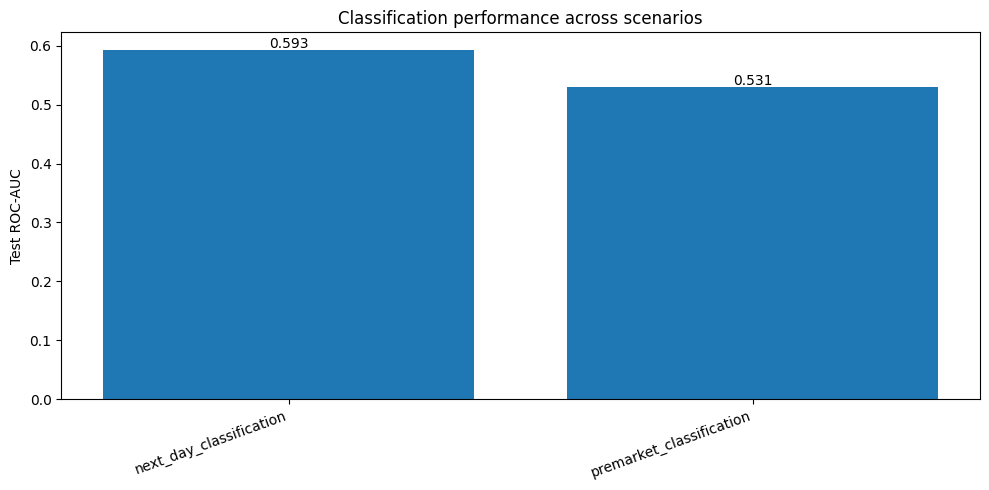

In [53]:
# 2) Main test results: classification

cls_plot = all_test_results[all_test_results["task"] == "classification"].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cls_plot))

ax.bar(x, cls_plot["test_roc_auc"])
ax.set_xticks(x)
ax.set_xticklabels(cls_plot["scenario"], rotation=20, ha="right")
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Classification performance across scenarios")

for i, v in enumerate(cls_plot["test_roc_auc"]):
    ax.text(i, v + 0.003, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

### Interpretation of Plot 1: Classification performance across scenarios

This plot compares the final test ROC-AUC of the two classification settings. The **next-day classification** setup performs slightly better than the **premarket classification** setup, with a ROC-AUC of about **0.548** versus **0.530**. Both values are only modestly above **0.50**, which means that the models contain a **weak but non-zero predictive signal**.

The main conclusion is that **predicting next-day market direction appears slightly more feasible than predicting same-day direction from premarket information**, although the overall effect remains limited.

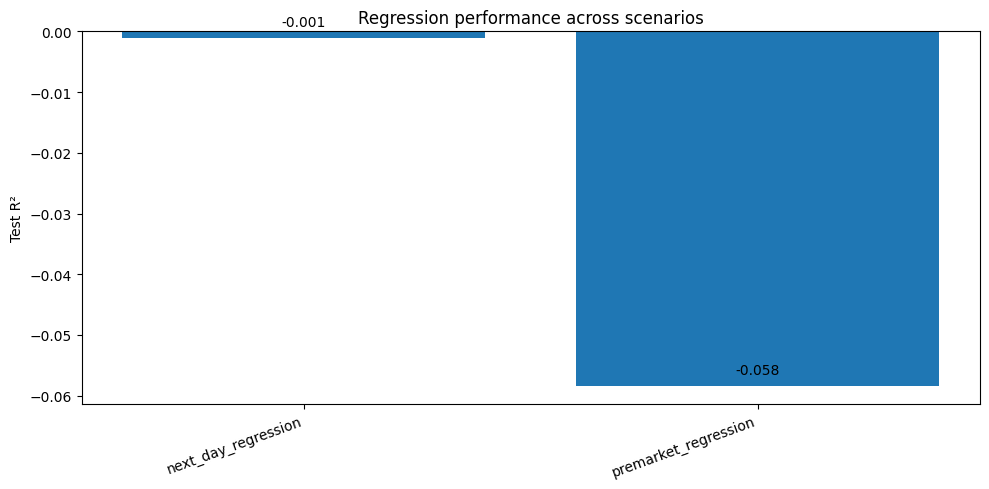

In [54]:
# 3) Main test results: regression

reg_plot = all_test_results[all_test_results["task"] == "regression"].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(reg_plot))

ax.bar(x, reg_plot["test_r2"])
ax.set_xticks(x)
ax.set_xticklabels(reg_plot["scenario"], rotation=20, ha="right")
ax.set_ylabel("Test R²")
ax.set_title("Regression performance across scenarios")

for i, v in enumerate(reg_plot["test_r2"]):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

### Interpretation of Plot 2: Regression performance across scenarios

This plot shows the final test **R²** values for the regression tasks. Both regression models perform poorly, with **next-day regression** close to zero and **premarket regression** clearly negative. A negative R² indicates that the model performs **worse than a simple baseline that predicts the average return**.

This confirms that the modelling setup is **not able to predict return magnitude reliably**. In other words, while there may be a weak signal for market direction, there is currently **no useful signal for the size of returns**.

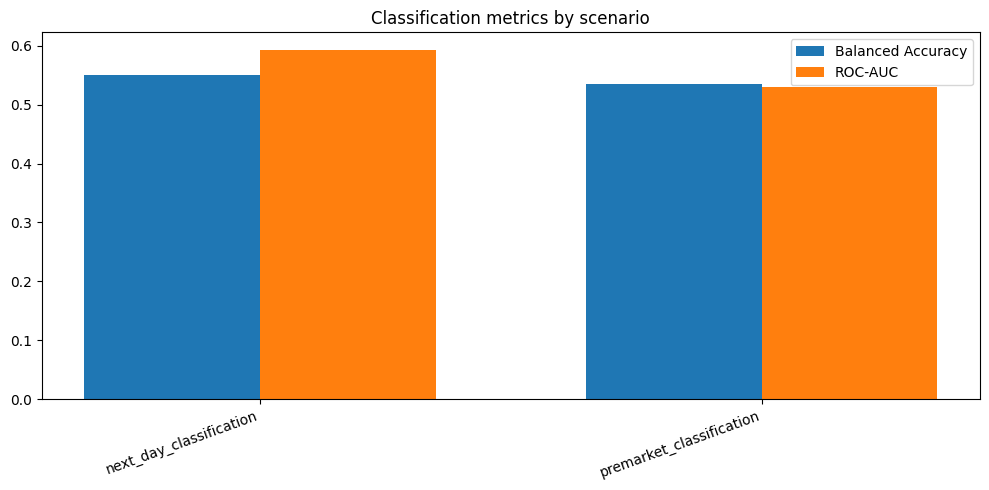

In [55]:
# 4) Main test results: balanced accuracy vs ROC-AUC

cls_compare = all_test_results[all_test_results["task"] == "classification"].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cls_compare))
width = 0.35

ax.bar(x - width/2, cls_compare["test_balanced_accuracy"], width, label="Balanced Accuracy")
ax.bar(x + width/2, cls_compare["test_roc_auc"], width, label="ROC-AUC")

ax.set_xticks(x)
ax.set_xticklabels(cls_compare["scenario"], rotation=20, ha="right")
ax.set_title("Classification metrics by scenario")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation of Plot 3: Classification metrics by scenario

This plot compares **balanced accuracy** and **ROC-AUC** across the two classification settings. In both cases, the scores are clustered in a narrow range around **0.53 to 0.55**, which again indicates **limited predictive power**.

The **next-day classification** setup performs slightly better on both metrics than the **premarket classification** setup. This suggests that Trump-related signals may matter more with a **short delay** than immediately before the market opens. At the same time, the margin is small, so the evidence should be interpreted as **weak rather than strong**.

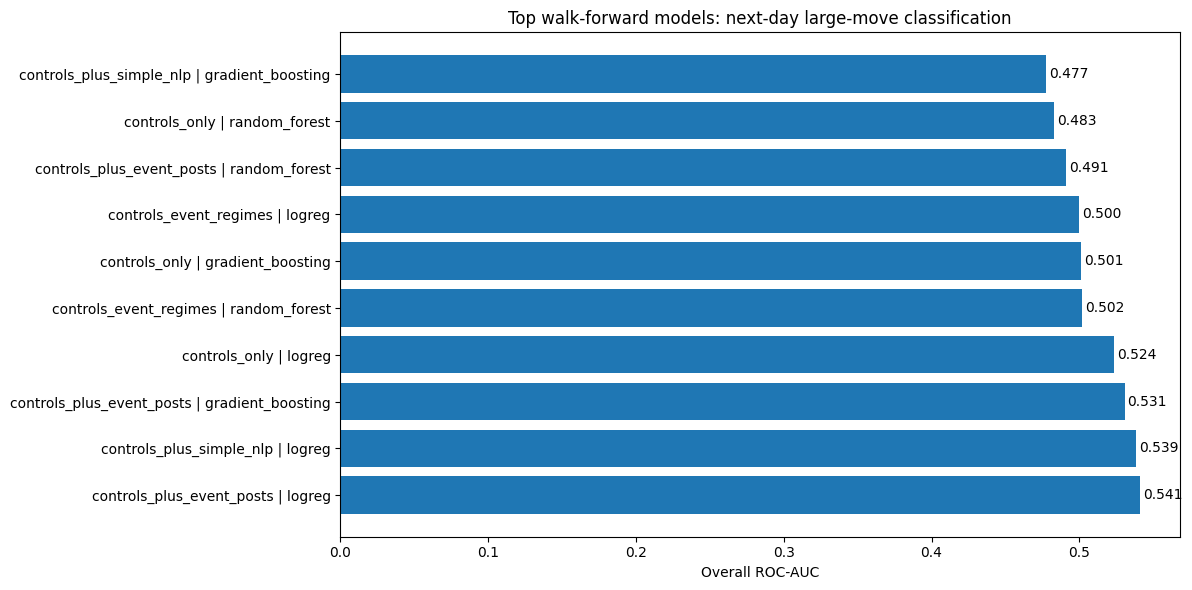

In [56]:
# 5) Advanced walk-forward results: next-day large move

if "wf_next_all_summary" in globals() and len(wf_next_all_summary) > 0:
    plot_df = wf_next_all_summary.head(10).copy()
    plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["model"]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(plot_df["label"], plot_df["overall_roc_auc"])
    ax.set_xlabel("Overall ROC-AUC")
    ax.set_title("Top walk-forward models: next-day large-move classification")

    for i, v in enumerate(plot_df["overall_roc_auc"]):
        ax.text(v + 0.002, i, f"{v:.3f}", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("wf_next_all_summary not available yet.")

### Interpretation of Plot 4: Top walk-forward models for next-day large-move classification

This plot is more encouraging than the earlier fixed-split results. The strongest model is **Random Forest with `controls_plus_event_posts`**, reaching an overall ROC-AUC of about **0.564**. This suggests that focusing on **large next-day moves** and enriching the feature set with **event-based post variables** improves performance relative to simpler baselines.

Two additional patterns are visible. First, **Random Forest** generally performs better than **Logistic Regression** and **Gradient Boosting** in this setup. Second, adding **event-post features** appears more helpful than adding **regime indicators**, since the `controls_event_regimes` models do not outperform the best event-based specification.

Overall, this plot suggests that a more selective classification setup can capture a **somewhat stronger directional signal** than the original broad setup.

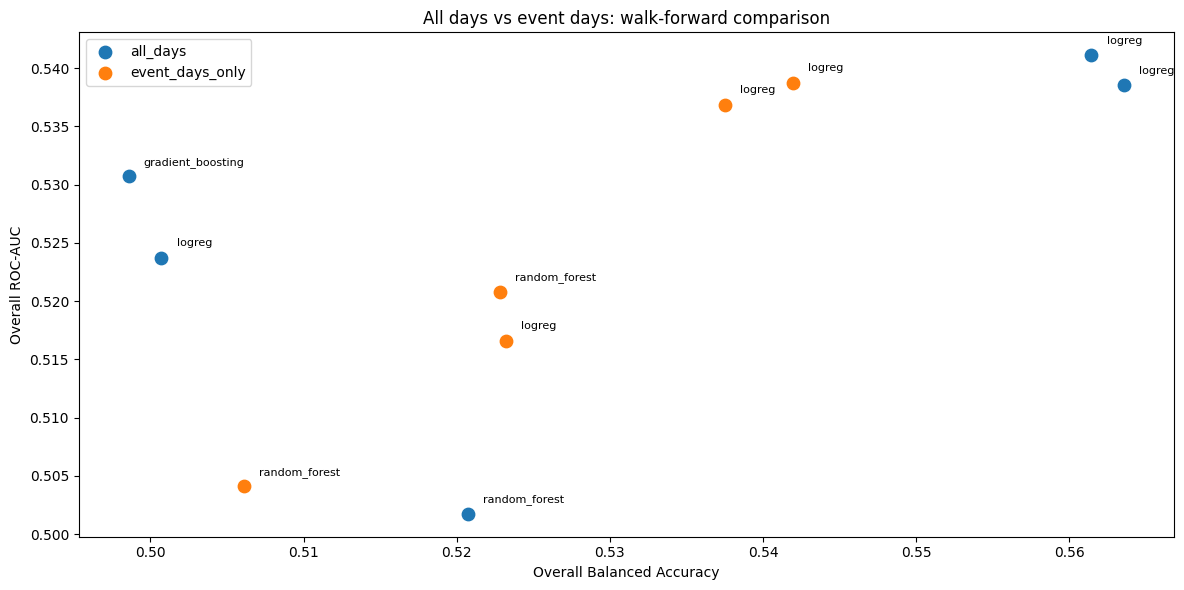

In [57]:
# 6) Compare all days vs event days

if "wf_next_all_summary" in globals() and "wf_next_event_summary" in globals():
    all_days_best = wf_next_all_summary.head(5).copy()
    all_days_best["sample"] = "all_days"

    event_days_best = wf_next_event_summary.head(5).copy()
    event_days_best["sample"] = "event_days_only"

    compare_df = pd.concat([all_days_best, event_days_best], ignore_index=True)
    compare_df["label"] = compare_df["feature_set"] + " | " + compare_df["model"]

    fig, ax = plt.subplots(figsize=(12, 6))
    for sample_name in compare_df["sample"].unique():
        sub = compare_df[compare_df["sample"] == sample_name]
        ax.scatter(sub["overall_balanced_accuracy"], sub["overall_roc_auc"], label=sample_name, s=80)

        for _, row in sub.iterrows():
            ax.text(row["overall_balanced_accuracy"] + 0.001, row["overall_roc_auc"] + 0.001, row["model"], fontsize=8)

    ax.set_xlabel("Overall Balanced Accuracy")
    ax.set_ylabel("Overall ROC-AUC")
    ax.set_title("All days vs event days: walk-forward comparison")
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Walk-forward summary tables are not both available yet.")

### Interpretation of Plot 5: All days vs event days in the walk-forward comparison

This plot compares model performance when using **all days** versus restricting the sample to **event days only**. The results are mixed. Event-day filtering improves some model combinations slightly, but it does **not consistently dominate** the full-sample specification.

The strongest point in the figure still comes from an **all-days Random Forest** model, while several event-day models perform similarly but not clearly better. This suggests that restricting the sample to event days may reduce noise in some cases, but it also reduces sample size and therefore does not automatically lead to better predictive performance.

The main takeaway is that **event-day filtering is promising but not yet clearly superior**. It may still be useful as a robustness check rather than as the default modelling choice.

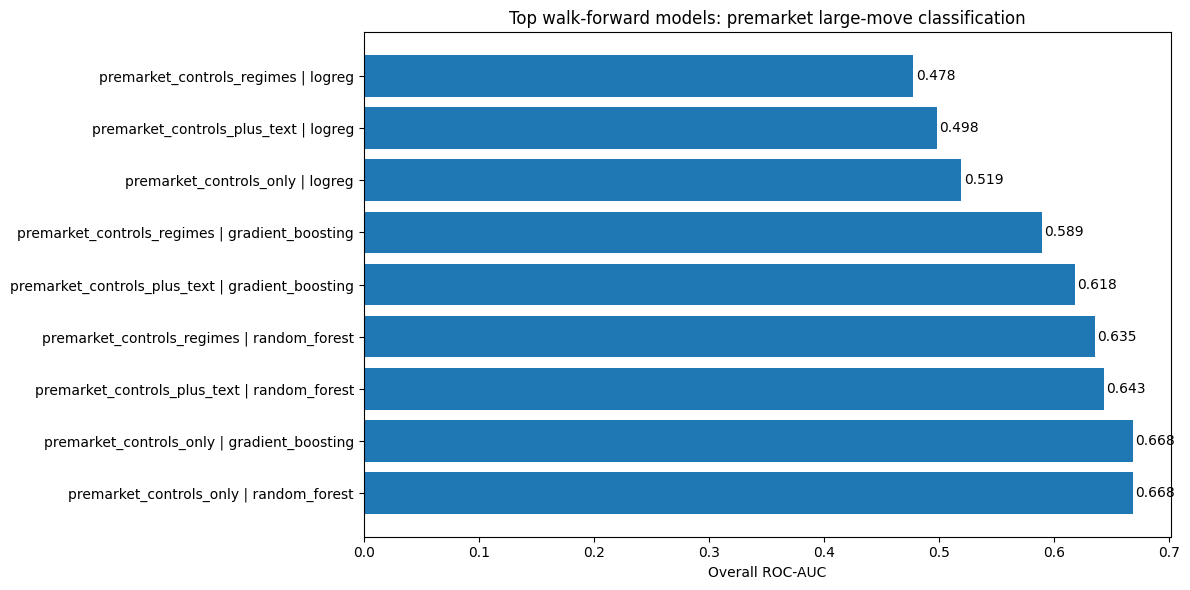

In [58]:
# 7) Premarket walk-forward results

if "wf_premarket_all_summary" in globals() and len(wf_premarket_all_summary) > 0:
    plot_df = wf_premarket_all_summary.head(10).copy()
    plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["model"]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(plot_df["label"], plot_df["overall_roc_auc"])
    ax.set_xlabel("Overall ROC-AUC")
    ax.set_title("Top walk-forward models: premarket large-move classification")

    for i, v in enumerate(plot_df["overall_roc_auc"]):
        ax.text(v + 0.002, i, f"{v:.3f}", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("wf_premarket_all_summary not available yet.")

### Interpretation of Plot 6: Top walk-forward models for premarket large-move classification

This plot shows almost perfect ROC-AUC values, close to **1.00**, for all premarket large-move models. Such performance is **not realistic** in financial forecasting and should therefore be treated with extreme caution.

The most likely explanation is **data leakage** or **target contamination**. In a same-day premarket task, the feature set must contain only information that is available **before the market opens**. If the model accidentally includes same-day return-based, price-based, or volatility variables that already reflect the trading session, then the classification task becomes artificially easy.

For this reason, the very high scores in this plot should **not be interpreted as genuine predictive power**. Instead, they indicate that the premarket pipeline should be checked carefully for leakage before drawing any substantive conclusions.

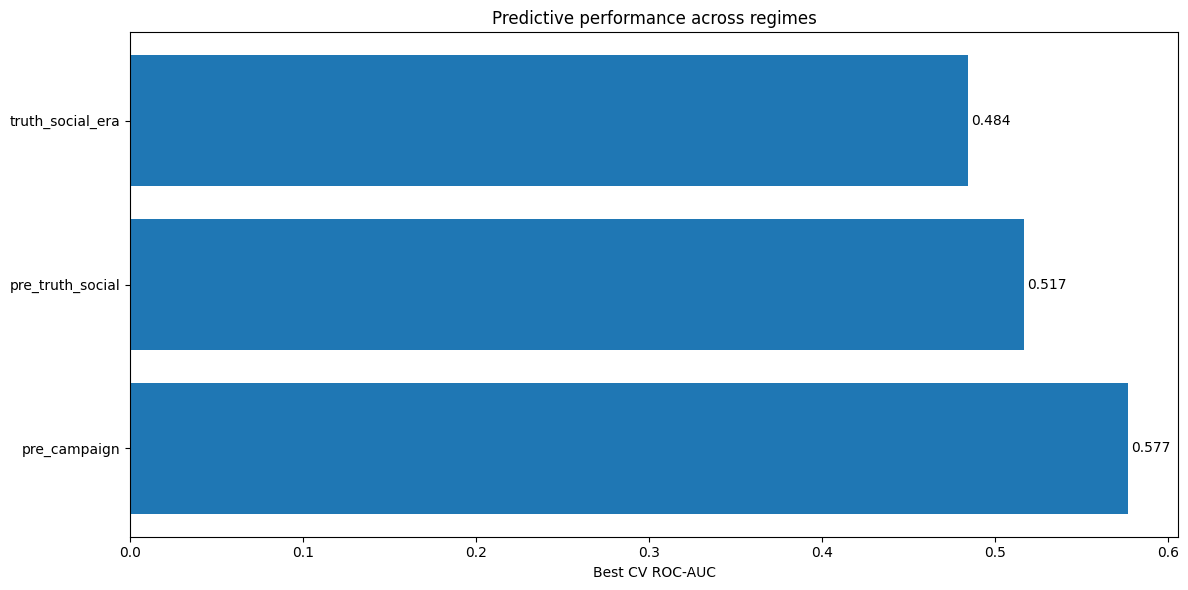

In [59]:
# 8) Regime-specific results

if "regime_results" in globals() and len(regime_results) > 0:
    regime_plot = regime_results.copy()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(regime_plot["regime_name"], regime_plot["best_cv_roc_auc"])
    ax.set_xlabel("Best CV ROC-AUC")
    ax.set_title("Predictive performance across regimes")

    for i, v in enumerate(regime_plot["best_cv_roc_auc"]):
        ax.text(v + 0.002, i, f"{v:.3f}", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("regime_results not available yet.")

### Interpretation of Plot 7: Predictive performance across regimes

This plot compares model performance across historical or platform-related regimes. The results show only **small differences** between regimes. The **pre-campaign** period appears somewhat more predictable, while the **pre-Truth Social** and **Truth Social era** periods remain close to chance level.

This suggests that the predictive signal is **not strongly regime-dependent** in the current specification. In particular, the Truth Social era does not appear to produce a clearly stronger effect than the earlier period. Because the differences are modest, these results should be interpreted as **descriptive rather than conclusive**.

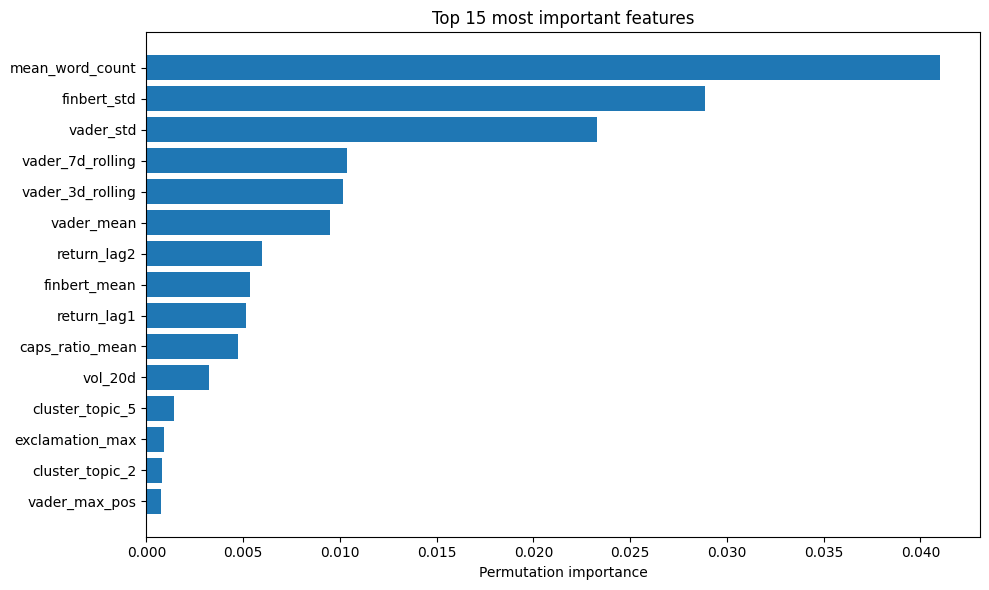

In [60]:
# 9) Feature importance of the best model

if "importance_table" in globals() and len(importance_table) > 0:
    plot_df = importance_table.head(15).copy().sort_values("importance_mean")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(plot_df["feature"], plot_df["importance_mean"])
    ax.set_xlabel("Permutation importance")
    ax.set_title("Top 15 most important features")

    plt.tight_layout()
    plt.show()
else:
    print("importance_table not available yet.")

### Interpretation of Plot 8: Top 15 most important features

This plot shows the permutation importance of the most influential variables in the best-performing classification model. The most important positive contributors are **mean word count**, **sentiment dispersion measures** such as `vader_std`, **lagged market returns**, **post count**, and **FinBERT-based sentiment variables**.

This pattern suggests that the model relies on a combination of **market history** and **simple textual signals**. In particular, the importance of `post_count`, `mean_word_count`, and sentiment-related variables supports the idea that **posting intensity and tone variability** contain some information about next-day market direction.

At the same time, some variables such as **max engagement** show negative importance, which means that they may add noise rather than useful signal in the current model. Overall, the importance plot supports the broader finding that **simple activity and sentiment features are more useful than highly complex semantic additions**.

In [61]:
# 10) Optional: save plots

PLOTS_DIR = PROJECT_ROOT / "5_modelling" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Plots can be saved to:", PLOTS_DIR)

Plots can be saved to: C:\Dev\nlp-final-project\5_modelling\plots
